In [8]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Tipos de Aprendizaje No Supervisado

**KMeans**

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV

np.random.seed(42)

# 1) Simular dataset de clientes
n = 600

edad = np.random.normal(40, 12, n).clip(18, 75)
ingreso_anual = np.random.normal(1500, 400, n).clip(400, 4000)  # en miles USD
gasto_mensual = np.random.normal(200, 80, n).clip(20, 600)
score_digital = np.random.normal(50, 20, n).clip(1, 100)
antiguedad = np.random.normal(5, 3, n).clip(0.5, 20)

df = pd.DataFrame({
    "edad": edad,
    "ingreso_anual": ingreso_anual,
    "gasto_mensual": gasto_mensual,
    "score_digital": score_digital,
    "antiguedad": antiguedad
})
df.head()

,edad,ingreso_anual,gasto_mensual,score_digital,antiguedad
0,45.960570,1802.795447,210.017960,88.023814,2.834787
1,38.340828,1131.133870,165.647557,48.786784,5.530463
2,47.772262,1847.842368,209.783800,35.831865,3.359960
3,58.276358,2042.255144,243.463842,19.725712,4.185035
4,37.190160,1665.373961,203.908806,13.937206,10.020356


Mejor K: {'kmeans__n_clusters': 6}
Silhouette: 0.152

Clientes por cluster:
cluster
0     87
1     91
2    108
3    102
4    117
5     95
Name: count, dtype: int64

Perfil promedio por cluster:
         edad  ingreso_anual  gasto_mensual  score_digital  antiguedad
cluster                                                               
0        34.0         1544.9          147.2           27.4         6.3
1        46.7         1957.7          180.4           53.5         3.1
2        36.0         1797.7          290.9           50.2         7.0
3        48.2         1223.0          237.9           38.6         3.3
4        28.9         1423.7          188.4           62.2         3.8
5        47.9         1302.5          173.6           62.0         7.8


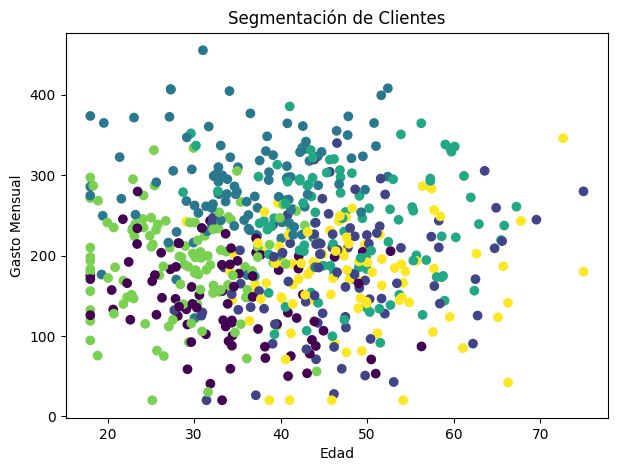

In [10]:
X = df.copy().values  # Convert X to a NumPy array immediately

# 2) Pipeline: escalado + clustering
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(random_state=42, n_init=10))
])

# 3) Buscar mejor K usando silhouette
param_grid = {
    "kmeans__n_clusters": [2, 3, 4, 5, 6]
}

def silhouette_scorer(estimator, X):
    X_scaled = estimator.named_steps["scaler"].transform(X)
    labels = estimator.named_steps["kmeans"].labels_
    return silhouette_score(X_scaled, labels)

search = GridSearchCV(
                    pipe,
                    param_grid,
                    scoring=silhouette_scorer,
                    cv=[(np.arange(len(X)), np.arange(len(X)))],  # Explicit integer indices for dummy CV
                    refit=True
            )

# Now X is already a NumPy array
search.fit(X)

print("Mejor K:", search.best_params_)
print("Silhouette:", round(search.best_score_, 3))

# 4) Agregar clusters al dataset
best_model = search.best_estimator_
df["cluster"] = best_model.named_steps["kmeans"].labels_

print("\nClientes por cluster:")
print(df["cluster"].value_counts().sort_index())

# 5) Perfil de clusters (clave en negocio)
perfil = df.groupby("cluster").mean().round(1)
print("\nPerfil promedio por cluster:")
print(perfil)

# 6) Visualización simple (Edad vs Gasto)
plt.figure(figsize=(7,5))
plt.scatter(df["edad"], df["gasto_mensual"], c=df["cluster"])
plt.xlabel("Edad")
plt.ylabel("Gasto Mensual")
plt.title("Segmentación de Clientes")
plt.show()

**PCA**

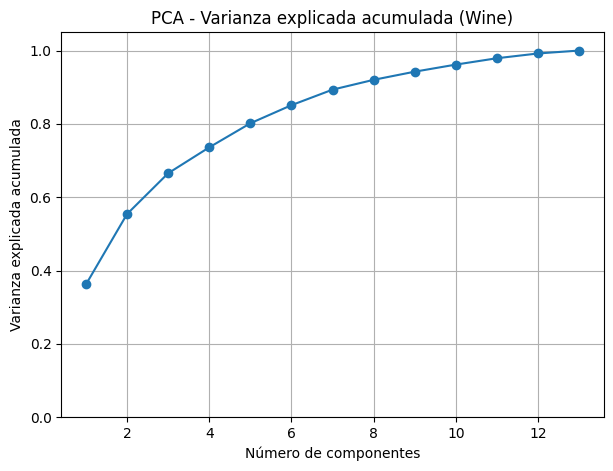

Componentes necesarios para >= 90% varianza: 8


In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = wine.data

pipe_full = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42))
])

pipe_full.fit(X)
pca_full = pipe_full.named_steps["pca"]

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada (Wine)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

# Ejemplo: mínimo número de componentes para alcanzar 90%
k_90 = int(np.argmax(cum_var >= 0.90) + 1)
print("Componentes necesarios para >= 90% varianza:", k_90)

**Reglas de Asociación con Apriori**

In [12]:
# Reglas de Asociación con Apriori (mlxtend)
# -------------------------------------------------
# 1) instala si estás en Colab / notebook:
# !pip -q install mlxtend

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 2) Dataset de ejemplo: lista de transacciones (cada transacción = lista de ítems)
transactions = [
    ["leche", "pan", "mantequilla"],
    ["cerveza", "pan"],
    ["leche", "pan", "huevos"],
    ["leche", "cerveza", "pan", "mantequilla"],
    ["pan", "mantequilla"],
    ["leche", "huevos"],
    ["cerveza", "papas", "pan"],
    ["leche", "papas", "pan"],
    ["leche", "pan"],
    ["cerveza", "pan", "mantequilla"]
]

# 3) One-hot encoding (formato requerido por Apriori)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_hot = pd.DataFrame(te_array, columns=te.columns_)

print("Matriz one-hot (primeras filas):")
print(df_hot.head())

# 4) Encontrar itemsets frecuentes
# min_support = proporción mínima de transacciones donde aparece el itemset
frequent_itemsets = apriori(df_hot, min_support=0.2, use_colnames=True)

# Agregamos longitud del itemset para filtrar mejor
frequent_itemsets["len"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)

print("\nItemsets frecuentes (top 10):")
print(frequent_itemsets.head(10))

# 5) Generar reglas de asociación
# metric puede ser 'confidence', 'lift', etc.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# Ordenar para ver las mejores (puedes cambiar por confidence/lift)
rules = rules.sort_values(["lift", "confidence"], ascending=False)

# 6) Mostrar reglas más relevantes (limpio)
def pretty_rules(df_rules, top=10):
    out = df_rules.copy()
    out["antecedents"] = out["antecedents"].apply(lambda x: ", ".join(list(x)))
    out["consequents"] = out["consequents"].apply(lambda x: ", ".join(list(x)))
    cols = ["antecedents", "consequents", "support", "confidence", "lift"]
    return out[cols].head(top)

print("\nReglas (top 10) por lift:")
print(pretty_rules(rules, top=10))

# 7) Filtros típicos (recomendado en práctica)
# Ej: reglas con buena confianza y lift > 1.2
filtered = rules[(rules["confidence"] >= 0.6) & (rules["lift"] >= 1.2)].copy()
filtered = filtered.sort_values(["lift", "confidence"], ascending=False)

print("\nReglas filtradas (confidence>=0.6 y lift>=1.2):")
print(pretty_rules(filtered, top=10))

Matriz one-hot (primeras filas):
   cerveza  huevos  leche  mantequilla   pan  papas
0    False   False   True         True  True  False
1     True   False  False        False  True  False
2    False    True   True        False  True  False
3     True   False   True         True  True  False
4    False   False  False         True  True  False

Itemsets frecuentes (top 10):
    support                itemsets  len
4       0.9                   (pan)    1
2       0.6                 (leche)    1
10      0.5            (pan, leche)    2
3       0.4           (mantequilla)    1
11      0.4      (pan, mantequilla)    2
7       0.4          (pan, cerveza)    2
0       0.4               (cerveza)    1
6       0.2  (cerveza, mantequilla)    2
5       0.2                 (papas)    1
1       0.2                (huevos)    1

Reglas (top 10) por lift:
         antecedents       consequents  support  confidence      lift
6             huevos             leche      0.2    1.000000  1.666667
7     

**Detección de Anomalías**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# 1) Datos sintéticos: 2 grupos "normales"
X_normal, _ = make_blobs(n_samples=500, centers=2, cluster_std=0.9, random_state=42)

# 2) Inyectar anomalías (puntos dispersos)
rng = np.random.RandomState(42)
X_anom = rng.uniform(low=-10, high=10, size=(25, 2))

X = np.vstack([X_normal, X_anom])
df = pd.DataFrame(X, columns=["x1", "x2"])
df.head()

,x1,x2
0,-2.940454,8.847193
1,-3.872870,10.244473
2,-3.386411,9.722662
3,-2.624323,8.154300
4,3.785420,4.342314


In [14]:
# 3) Pipeline: escalar -> Isolation Forest
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("iso", IsolationForest(
        n_estimators=200,
        contamination=0.05,  # aprox % esperado de anomalías (ajústalo)
        random_state=42
    ))
])

pipe.fit(df[["x1", "x2"]])

# 4) Predicción: -1 anomalía, +1 normal
pred = pipe.predict(df[["x1", "x2"]])
df["es_anomalia"] = (pred == -1)

# 5) Score de anomalía (más bajo = más anómalo)
scores = pipe.named_steps["iso"].decision_function(
    pipe.named_steps["scaler"].transform(df[["x1", "x2"]])
)
df["score_anomalia"] = scores

print("Total anomalías detectadas:", df["es_anomalia"].sum())
print("\nTop 5 más anómalos (score más bajo):")
print(df.sort_values("score_anomalia").head(5))

Total anomalías detectadas: 27

Top 5 más anómalos (score más bajo):
           x1        x2  es_anomalia  score_anomalia
502 -6.879627 -6.880110         True       -0.188480
514  1.848291 -9.070992         True       -0.182898
507 -6.363501 -6.331910         True       -0.168377
518 -3.907725 -8.046558         True       -0.168222
506  6.648853 -5.753218         True       -0.157144


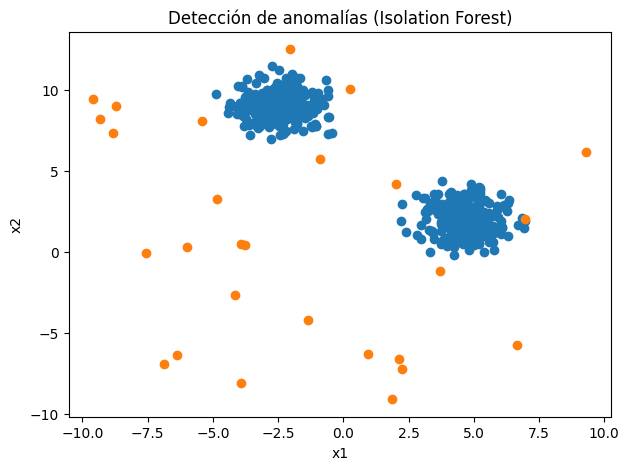

In [15]:
# 6) Visualización
plt.figure(figsize=(7, 5))
plt.scatter(df.loc[~df["es_anomalia"], "x1"], df.loc[~df["es_anomalia"], "x2"])
plt.scatter(df.loc[df["es_anomalia"], "x1"], df.loc[df["es_anomalia"], "x2"])
plt.title("Detección de anomalías (Isolation Forest)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()